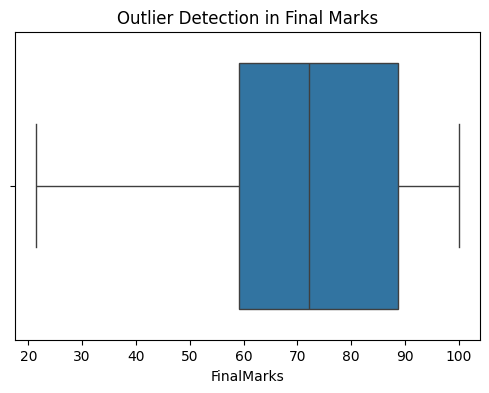

In [29]:
# Student Performance Analysis & Prediction

# Objective :
# The goal of this project is to analyze student academic data, 
# clean real-world issues such as missing values and inconsistent entries, 
# and build a basic machine learning model to predict final marks based on 
# study hours and attendance.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/students.csv')
# df.head()
# df.shape
# df.info()
# df.describe()
# df.isna().sum()
df.fillna({'StudyHours':df['StudyHours'].median()},inplace=True)
df.fillna({'Attendance':df['Attendance'].median()},inplace=True)
# df.isna().sum()
df["City"] = df["City"].str.lower().str.strip()
df["City"].value_counts()
df["City"] = df["City"].str.title()
df.drop_duplicates(inplace=True)
plt.figure(figsize=(6,4))
sns.boxplot(x=df["FinalMarks"])
plt.title("Outlier Detection in Final Marks")
plt.show()

In [33]:
# Final Clean data
df.head()
df.describe()

# Saving clean data
df.to_csv("../data/students_cleaned.csv", index=False)


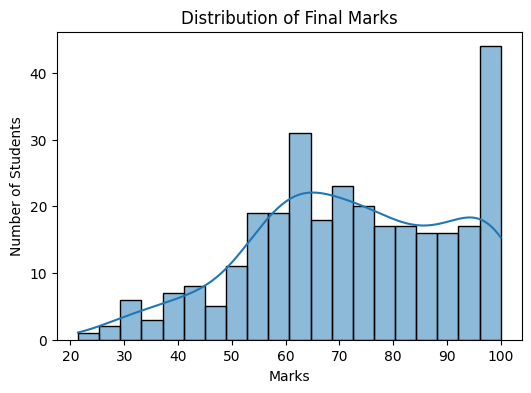

In [35]:
## Exploratory Data Analysis (EDA)

# In this section, we explore patterns and relationships in the 
# cleaned student dataset to understand factors affecting academic performance.

df["FinalMarks"].mean()


plt.figure(figsize=(6,4))
sns.histplot(df["FinalMarks"], bins=20, kde=True)
plt.title("Distribution of Final Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()



In [ ]:
city_avg = df.groupby("City")["FinalMarks"].mean().sort_values(ascending=False)
city_avg

City
Mumbai       75.626111
Ahmedabad    72.178041
Delhi        70.971527
Name: FinalMarks, dtype: float64

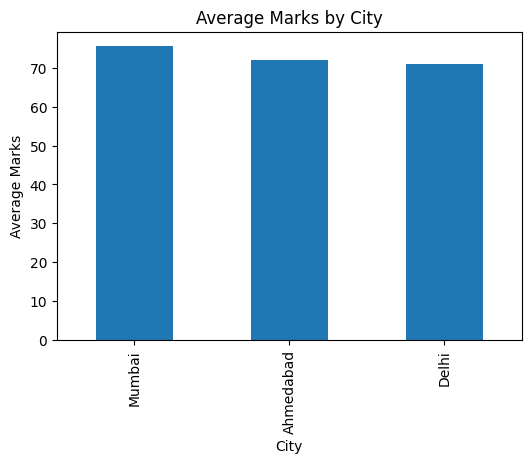

In [37]:
plt.figure(figsize=(6,4))
city_avg.plot(kind="bar")
plt.title("Average Marks by City")
plt.ylabel("Average Marks")
plt.show()


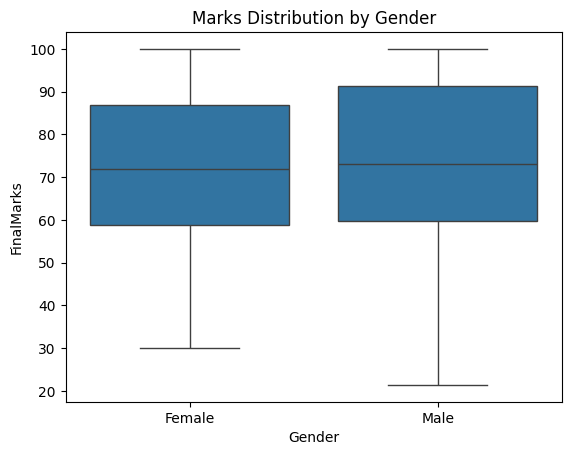

In [39]:
df.groupby("Gender")["FinalMarks"].mean()


sns.boxplot(x="Gender", y="FinalMarks", data=df)
plt.title("Marks Distribution by Gender")
plt.show()



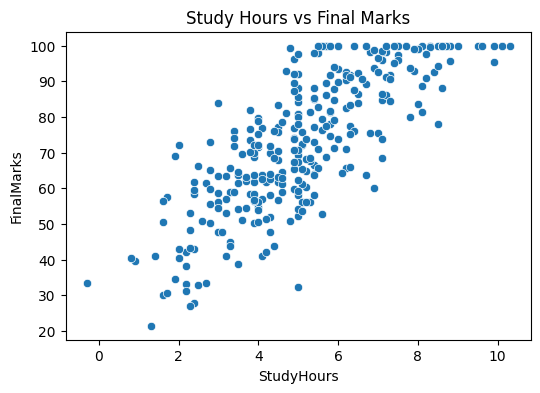

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="StudyHours", y="FinalMarks", data=df)
plt.title("Study Hours vs Final Marks")
plt.show()


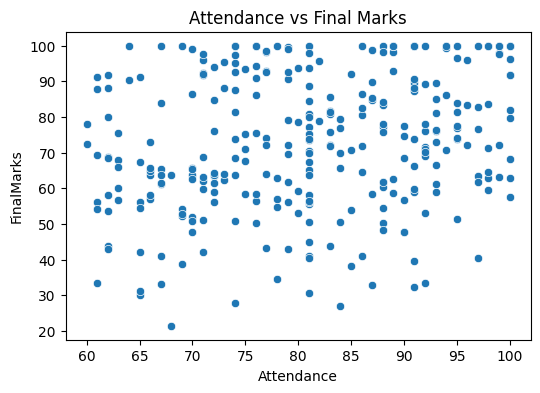

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Attendance", y="FinalMarks", data=df)
plt.title("Attendance vs Final Marks")
plt.show()


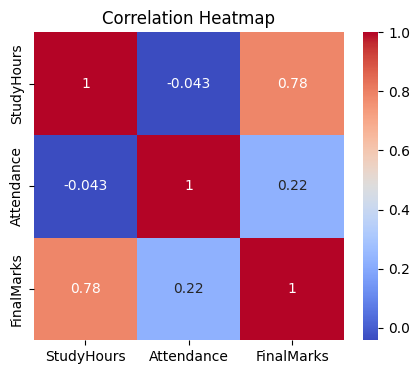

In [43]:
corr = df[["StudyHours", "Attendance", "FinalMarks"]].corr()
corr


plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [44]:
df.sort_values("FinalMarks", ascending=False).head(5)


,StudentId,Name,Age,Gender,City,StudyHours,Attendance,FinalMarks
273,274,Aadhya,24,Female,Ahmedabad,7.4,89.0,100.0
267,268,Pihu,18,Male,Mumbai,9.9,94.0,100.0
255,256,Diya,23,Male,Ahmedabad,5.5,91.0,100.0
23,24,Aditya,18,Male,Delhi,7.7,64.0,100.0
32,33,Ishaan,23,Male,Ahmedabad,5.6,95.0,100.0


In [ ]:
# Key Insights :
# - Study hours show a strong positive relationship with final marks.
# - Attendance also impacts performance but less strongly.
# - City-wise differences exist but are not extreme.
# - Gender does not show a significant performance gap.


In [45]:
## Machine Learning Model

# In this section, we build a regression model to predict students' 
# final marks based on study hours and attendance.

X = df[["StudyHours", "Attendance"]]
y = df["FinalMarks"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.6648561065818736
MAE: 9.341393536578524


In [49]:
# Model Coefficients
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})


,Feature,Coefficient
0,StudyHours,7.844009
1,Attendance,0.429661


In [50]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
# Evaluate Ridge Regression

ridge_pred = ridge_model.predict(X_test)

print("Ridge R2 Score:", r2_score(y_test, ridge_pred))
print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))


Ridge R2 Score: 0.6648914795835437
Ridge MAE: 9.339050832546029


In [ ]:
### Model Comparison
# - Linear Regression: Simple and interpretable
# - Ridge Regression: Better generalization when multicollinearity exists

In [52]:
# Predict for new student
new_student = pd.DataFrame({
    "StudyHours": [6],
    "Attendance": [85]
})

predicted_marks = ridge_model.predict(new_student)
predicted_marks


array([81.63911579])

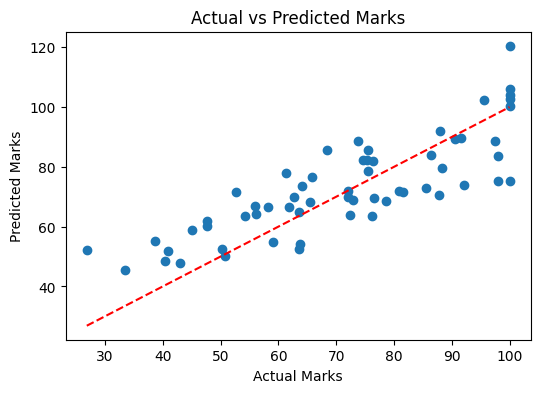

In [ ]:
# Actual vs Predicted Plot

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()


In [ ]:
## Conclusion
# - Data cleaning significantly improved data quality.
# - Study hours and attendance are strong predictors of marks.
# - Ridge regression slightly improved model stability.
# - The model can be extended using more features and advanced algorithms.
